You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
penguins_df = pd.read_csv('datasets/penguins.csv')
print(penguins_df.head())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3              36.7             19.3              193.0       3450.0  FEMALE
4              39.3             20.6              190.0       3650.0    MALE


In [5]:
# Create dummy variables for the categorical column
penguins_df = pd.get_dummies(penguins_df, columns=['sex'], drop_first=True)

print(penguins_df.head())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex_MALE
0              39.1             18.7              181.0       3750.0      True
1              39.5             17.4              186.0       3800.0     False
2              40.3             18.0              195.0       3250.0     False
3              36.7             19.3              193.0       3450.0     False
4              39.3             20.6              190.0       3650.0      True


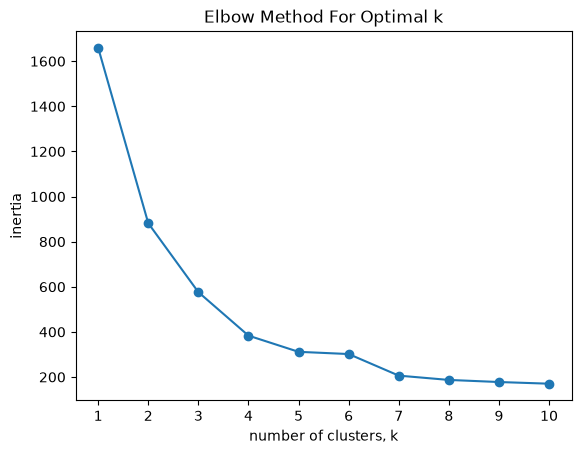

In [7]:
# Standardize
scaler = StandardScaler() 

# Perform elbow method to find the optimal number of clusters
scaled_X = scaler.fit_transform(penguins_df)

ks = range(1, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_X)
    inertias.append(kmeans.inertia_)
    
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.title('Elbow Method For Optimal k')
plt.show()

In [11]:
# Run with optimal k
optimal_k = 4  # Based on the elbow method

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(scaled_X)

penguins_df['cluster'] = labels

stat_penguins = penguins_df.groupby('cluster').mean()

print(stat_penguins)

         culmen_length_mm  culmen_depth_mm  ...  body_mass_g  sex_MALE
cluster                                     ...                       
0               43.878302        19.111321  ...  4006.603774       1.0
1               49.473770        15.718033  ...  5484.836066       1.0
2               40.217757        17.611215  ...  3419.158879       0.0
3               45.563793        14.237931  ...  4679.741379       0.0

[4 rows x 5 columns]
